
# Embeddings, Similaridade Semântica e Retrieval
## Microdemo visual para entender uma peça central de RAG

**Objetivo:** visualizar como textos são representados em um espaço vetorial e como uma consulta recupera trechos semanticamente próximos.

> **Não vamos construir um RAG completo.**
> Vamos abrir apenas a parte de representação vetorial + retrieval.

### O que veremos
1. embeddings de frases;
2. agrupamentos semânticos em 2D com **PCA**;
3. recuperação por similaridade;
4. conflito entre documentos semanticamente parecidos;
5. por que metadata, versão e regras continuam necessárias.




## 1. Preparação

A instalação e o **primeiro carregamento do modelo** são as etapas que mais podem demorar no Colab.

Depois que o modelo estiver carregado, gerar o embedding de uma única query deve ser rápido.


In [ ]:
!pip -q install sentence-transformers

In [1]:

import time
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

pd.set_option("display.max_colwidth", 120)



## 2. Carregando um modelo pequeno de embeddings

Usaremos um MiniLM leve, adequado para uma demonstração rápida.

> O tempo desta célula inclui o download na primeira execução da sessão.


In [2]:

start = time.perf_counter()

model = SentenceTransformer("sentence-transformers/paraphrase-MiniLM-L3-v2")

elapsed = time.perf_counter() - start
print(f"Modelo carregado em {elapsed:.2f} s")


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

c:\Users\cstefano\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\cstefano\.cache\huggingface\hub\models--sentence-transformers--paraphrase-MiniLM-L3-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo carregado em 12.30 s



# 3. Visualizando proximidade semântica

Embeddings possuem centenas de dimensões. Para fins didáticos, vamos usar **PCA** para projetá-los em duas dimensões.

> O PCA distorce parte da geometria original. O gráfico serve para **intuição visual**, não para avaliar embeddings de produção.


In [3]:
sentences = [
    "Funcionários podem trabalhar de casa três dias por semana.",
    "O trabalho híbrido permite alternar entre casa e escritório.",
    "Colaboradores remotos acessam sistemas corporativos de casa.",
    "Funcionários têm direito a férias anuais remuneradas.",
    "A equipe pode solicitar dias de férias pelo portal de RH.",
    "A licença anual deve ser aprovada pelo gestor do funcionário.",
    "Despesas de negócios exigem um recibo válido.",
    "Funcionários devem enviar despesas de viagem pela plataforma.",
    "Reembolsos de refeição são limitados pela política da empresa.",
    "Autenticação multifator é obrigatória para acesso remoto.",
    "Funcionários devem proteger suas senhas corporativas.",
    "Incidentes de segurança devem ser relatados ao time de TI."
]

labels = [
    "Remoto 1", "Remoto 2", "Remoto 3",
    "Férias 1", "Férias 2", "Férias 3",
    "Despesa 1", "Despesa 2", "Despesa 3",
    "Segurança 1", "Segurança 2", "Segurança 3"
]

semantic_embeddings = model.encode(sentences, normalize_embeddings=True)
coords = PCA(n_components=2).fit_transform(semantic_embeddings)

plot_df = pd.DataFrame({
    "label": labels,
    "text": sentences,
    "x": coords[:, 0],
    "y": coords[:, 1]
})

display(plot_df.head())

,label,text,x,y
0,Remoto 1,Funcionários podem trabalhar de casa três dias por semana.,-0.217214,-0.163861
1,Remoto 2,O trabalho híbrido permite alternar entre casa e escritório.,-0.627304,-0.059878
2,Remoto 3,Colaboradores remotos acessam sistemas corporativos de casa.,0.090496,-0.076670
3,Férias 1,Funcionários têm direito a férias anuais remuneradas.,0.427846,0.345374
4,Férias 2,A equipe pode solicitar dias de férias pelo portal de RH.,0.067958,0.347337


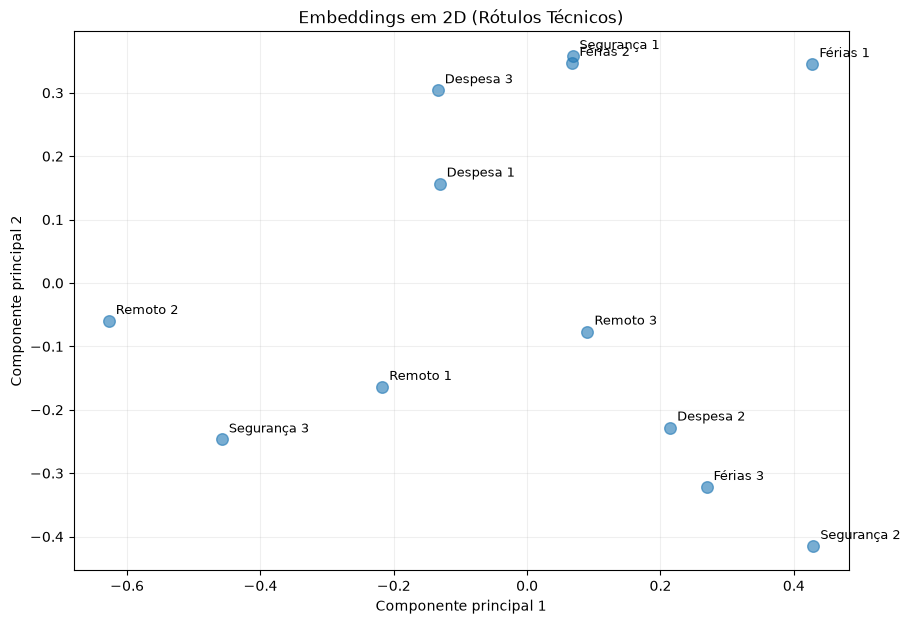

In [4]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(plot_df["x"], plot_df["y"], s=70, alpha=0.6)

for _, row in plot_df.iterrows():
    ax.annotate(
        row["label"],
        (row["x"], row["y"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

ax.set_title("Embeddings em 2D (Rótulos Técnicos)")
ax.set_xlabel("Componente principal 1")
ax.set_ylabel("Componente principal 2")
ax.grid(alpha=0.2)
plt.show()

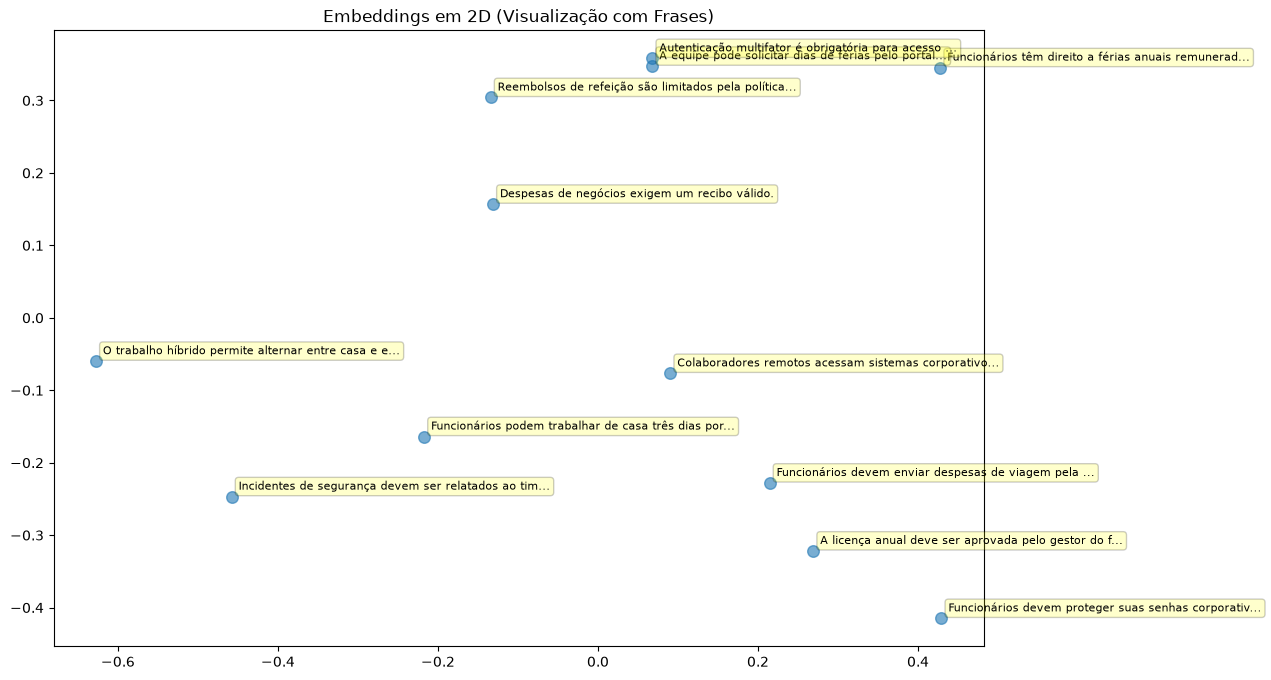

In [5]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(plot_df["x"], plot_df["y"], s=70, alpha=0.6)

for _, row in plot_df.iterrows():
    display_text = (row["text"][:50] + '...') if len(row["text"]) > 50 else row["text"]
    ax.annotate(
        display_text,
        (row["x"], row["y"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.2)
    )

ax.set_title("Embeddings em 2D (Visualização com Frases)")
plt.show()

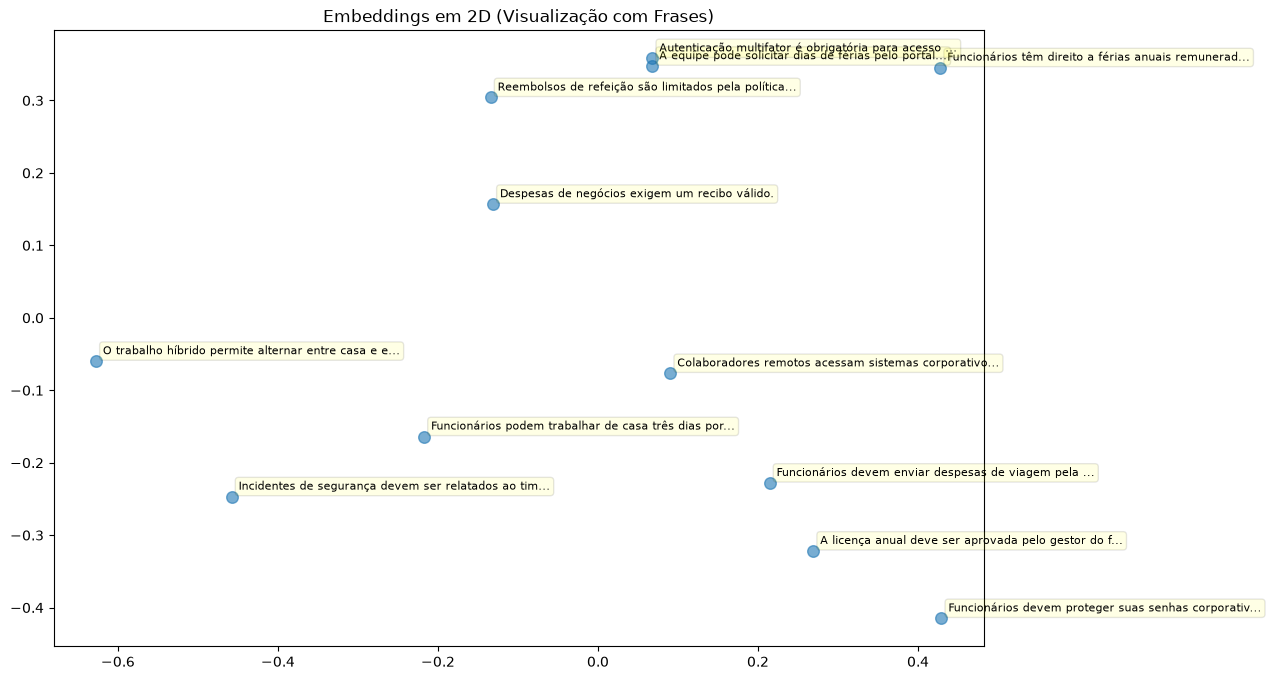

In [6]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(plot_df["x"], plot_df["y"], s=70, alpha=0.6)

for _, row in plot_df.iterrows():
    display_text = (row["text"][:50] + '...') if len(row["text"]) > 50 else row["text"]
    ax.annotate(
        display_text,
        (row["x"], row["y"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.1)
    )

ax.set_title("Embeddings em 2D (Visualização com Frases)")
plt.show()


### Checagens
- Frases sobre temas parecidos aparecem próximas?
- Elas usam necessariamente as mesmas palavras?
- Algum ponto ficou em uma região inesperada?

> **Embeddings tornam possível comparar semanticamente textos que não usam exatamente o mesmo vocabulário.**


## 4. Nosso mini corpus corporativo

In [7]:
documents = [
    {
        "id": "DOC_01",
        "title": "Política de Trabalho Remoto — Brasil — 2026",
        "country": "Brasil",
        "year": 2026,
        "status": "active",
        "text": "Funcionários elegíveis no Brasil podem trabalhar remotamente até três dias por semana."
    },
    {
        "id": "DOC_02",
        "title": "Política de Férias — Brasil",
        "country": "Brasil",
        "year": 2026,
        "status": "active",
        "text": "Funcionários no Brasil têm direito a férias anuais remuneradas de acordo com as leis trabalhistas locais."
    },
    {
        "id": "DOC_03",
        "title": "Política de Reembolso de Despesas",
        "country": "Global",
        "year": 2026,
        "status": "active",
        "text": "Despesas de negócios devem ser enviadas pela plataforma corporativa com o recibo correspondente."
    },
    {
        "id": "DOC_04",
        "title": "Política de Licença Parental",
        "country": "Global",
        "year": 2026,
        "status": "active",
        "text": "Funcionários elegíveis podem solicitar licença parental conforme a legislação local e benefícios da empresa."
    },
    {
        "id": "DOC_05",
        "title": "Política de Segurança da Informação",
        "country": "Global",
        "year": 2026,
        "status": "active",
        "text": "Funcionários devem usar autenticação multifator ao acessar sistemas corporativos remotamente."
    },
    {
        "id": "DOC_06",
        "title": "FAQ de Trabalho Flexível",
        "country": "Brasil",
        "year": 2026,
        "status": "active",
        "text": "Acordos de trabalho híbrido permitem que funcionários brasileiros combinem trabalho no escritório e remoto."
    },
    {
        "id": "DOC_07",
        "title": "Código de Vestimenta (Dress Code)",
        "country": "Brasil",
        "year": 2025,
        "status": "active",
        "text": "A empresa adota um estilo business casual. Bermudas são permitidas apenas em sextas-feiras casuais."
    },
    {
        "id": "DOC_08",
        "title": "Política de Plano de Saúde",
        "country": "Brasil",
        "year": 2026,
        "status": "active",
        "text": "O plano de saúde cobre consultas, exames e internações hospitalares para o titular e dependentes."
    },
    {
        "id": "DOC_09",
        "title": "Calendário de Feriados",
        "country": "Brasil",
        "year": 2026,
        "status": "active",
        "text": "A lista oficial de feriados nacionais e pontes para o ano vigente está disponível no portal do RH."
    },
    {
        "id": "DOC_10",
        "title": "Auxílio Creche",
        "country": "Brasil",
        "year": 2026,
        "status": "active",
        "text": "Funcionários com filhos de até 5 anos têm direito a um reembolso mensal para despesas com creches credenciadas."
    }
]

df = pd.DataFrame(documents)
display(df[["id", "title", "text"]])

,id,title,text
0,DOC_01,Política de Trabalho Remoto — Brasil — 2026,Funcionários elegíveis no Brasil podem trabalhar remotamente até três dias por semana.
1,DOC_02,Política de Férias — Brasil,Funcionários no Brasil têm direito a férias anuais remuneradas de acordo com as leis trabalhistas locais.
2,DOC_03,Política de Reembolso de Despesas,Despesas de negócios devem ser enviadas pela plataforma corporativa com o recibo correspondente.
3,DOC_04,Política de Licença Parental,Funcionários elegíveis podem solicitar licença parental conforme a legislação local e benefícios da empresa.
4,DOC_05,Política de Segurança da Informação,Funcionários devem usar autenticação multifator ao acessar sistemas corporativos remotamente.
5,DOC_06,FAQ de Trabalho Flexível,Acordos de trabalho híbrido permitem que funcionários brasileiros combinem trabalho no escritório e remoto.
6,DOC_07,Código de Vestimenta (Dress Code),A empresa adota um estilo business casual. Bermudas são permitidas apenas em sextas-feiras casuais.
7,DOC_08,Política de Plano de Saúde,"O plano de saúde cobre consultas, exames e internações hospitalares para o titular e dependentes."
8,DOC_09,Calendário de Feriados,A lista oficial de feriados nacionais e pontes para o ano vigente está disponível no portal do RH.
9,DOC_10,Auxílio Creche,Funcionários com filhos de até 5 anos têm direito a um reembolso mensal para despesas com creches credenciadas.



## 5. Pré-computando embeddings dos documentos

Em um sistema real, embeddings da base normalmente são calculados **antes da consulta** e armazenados em um índice.


In [8]:

start = time.perf_counter()

document_embeddings = model.encode(
    df["text"].tolist(),
    normalize_embeddings=True
)

elapsed = time.perf_counter() - start
print("Shape:", document_embeddings.shape)
print(f"Embeddings dos documentos calculados em {elapsed:.4f} s")


Shape: (10, 384)
Embeddings dos documentos calculados em 0.0482 s


In [9]:
# Atualizando embeddings após a inserção de novos documentos
document_embeddings = model.encode(df['text'].tolist(), normalize_embeddings=True)
print(f"Embeddings atualizados para {len(df)} documentos.")

Embeddings atualizados para 10 documentos.



# 6. Query + similaridade

Com embeddings normalizados, o produto vetorial equivale à similaridade de cosseno:

```python
scores = document_embeddings @ query_embedding
```

Isso evita trabalho extra e deixa o mecanismo transparente.


In [10]:

def retrieve(query, dataframe, embeddings, top_k=3):
    start = time.perf_counter()

    query_embedding = model.encode(
        query,
        normalize_embeddings=True
    )

    encoding_time = time.perf_counter() - start

    scores = embeddings @ query_embedding

    result = dataframe.copy()
    result["similarity"] = scores

    result = (
        result
        .sort_values("similarity", ascending=False)
        .head(top_k)
        [["id", "title", "text", "similarity"]]
        .reset_index(drop=True)
    )

    total_time = time.perf_counter() - start

    print(f"Embedding da query: {encoding_time:.4f} s")
    print(f"Retrieval total:    {total_time:.4f} s")

    return result


In [11]:
retrieve(
    "Quero uma receita de bolo",
    df,
    document_embeddings,
    top_k=10
)

Embedding da query: 0.0193 s
Retrieval total:    0.0248 s


,id,title,text,similarity
0,DOC_03,Política de Reembolso de Despesas,Despesas de negócios devem ser enviadas pela plataforma corporativa com o recibo correspondente.,0.494966
1,DOC_02,Política de Férias — Brasil,Funcionários no Brasil têm direito a férias anuais remuneradas de acordo com as leis trabalhistas locais.,0.334395
2,DOC_09,Calendário de Feriados,A lista oficial de feriados nacionais e pontes para o ano vigente está disponível no portal do RH.,0.328342
3,DOC_06,FAQ de Trabalho Flexível,Acordos de trabalho híbrido permitem que funcionários brasileiros combinem trabalho no escritório e remoto.,0.316034
4,DOC_01,Política de Trabalho Remoto — Brasil — 2026,Funcionários elegíveis no Brasil podem trabalhar remotamente até três dias por semana.,0.301855
5,DOC_10,Auxílio Creche,Funcionários com filhos de até 5 anos têm direito a um reembolso mensal para despesas com creches credenciadas.,0.253560
6,DOC_08,Política de Plano de Saúde,"O plano de saúde cobre consultas, exames e internações hospitalares para o titular e dependentes.",0.238408
7,DOC_05,Política de Segurança da Informação,Funcionários devem usar autenticação multifator ao acessar sistemas corporativos remotamente.,0.233271
8,DOC_04,Política de Licença Parental,Funcionários elegíveis podem solicitar licença parental conforme a legislação local e benefícios da empresa.,0.228717
9,DOC_07,Código de Vestimenta (Dress Code),A empresa adota um estilo business casual. Bermudas são permitidas apenas em sextas-feiras casuais.,0.174163


In [12]:
query_exemplo = "Qual a regra para trabalho remoto no Brasil?"

for k in [1, 5, 10]:
    print(f"\n--- Resultados com top_k={k} ---")
    res = retrieve(query_exemplo, df, document_embeddings, top_k=k)
    display(res)


--- Resultados com top_k=1 ---
Embedding da query: 0.0182 s
Retrieval total:    0.0194 s


,id,title,text,similarity
0,DOC_01,Política de Trabalho Remoto — Brasil — 2026,Funcionários elegíveis no Brasil podem trabalhar remotamente até três dias por semana.,0.62282



--- Resultados com top_k=5 ---
Embedding da query: 0.0151 s
Retrieval total:    0.0168 s


,id,title,text,similarity
0,DOC_01,Política de Trabalho Remoto — Brasil — 2026,Funcionários elegíveis no Brasil podem trabalhar remotamente até três dias por semana.,0.622820
1,DOC_06,FAQ de Trabalho Flexível,Acordos de trabalho híbrido permitem que funcionários brasileiros combinem trabalho no escritório e remoto.,0.596792
2,DOC_02,Política de Férias — Brasil,Funcionários no Brasil têm direito a férias anuais remuneradas de acordo com as leis trabalhistas locais.,0.522938
3,DOC_09,Calendário de Feriados,A lista oficial de feriados nacionais e pontes para o ano vigente está disponível no portal do RH.,0.422194
4,DOC_10,Auxílio Creche,Funcionários com filhos de até 5 anos têm direito a um reembolso mensal para despesas com creches credenciadas.,0.387312



--- Resultados com top_k=10 ---
Embedding da query: 0.0102 s
Retrieval total:    0.0123 s


,id,title,text,similarity
0,DOC_01,Política de Trabalho Remoto — Brasil — 2026,Funcionários elegíveis no Brasil podem trabalhar remotamente até três dias por semana.,0.622820
1,DOC_06,FAQ de Trabalho Flexível,Acordos de trabalho híbrido permitem que funcionários brasileiros combinem trabalho no escritório e remoto.,0.596792
2,DOC_02,Política de Férias — Brasil,Funcionários no Brasil têm direito a férias anuais remuneradas de acordo com as leis trabalhistas locais.,0.522938
3,DOC_09,Calendário de Feriados,A lista oficial de feriados nacionais e pontes para o ano vigente está disponível no portal do RH.,0.422194
4,DOC_10,Auxílio Creche,Funcionários com filhos de até 5 anos têm direito a um reembolso mensal para despesas com creches credenciadas.,0.387312
5,DOC_04,Política de Licença Parental,Funcionários elegíveis podem solicitar licença parental conforme a legislação local e benefícios da empresa.,0.366599
6,DOC_03,Política de Reembolso de Despesas,Despesas de negócios devem ser enviadas pela plataforma corporativa com o recibo correspondente.,0.365258
7,DOC_07,Código de Vestimenta (Dress Code),A empresa adota um estilo business casual. Bermudas são permitidas apenas em sextas-feiras casuais.,0.327648
8,DOC_08,Política de Plano de Saúde,"O plano de saúde cobre consultas, exames e internações hospitalares para o titular e dependentes.",0.278459
9,DOC_05,Política de Segurança da Informação,Funcionários devem usar autenticação multifator ao acessar sistemas corporativos remotamente.,0.259634



### O que observar

A pergunta usa **"work from home"**, enquanto o documento principal usa **"work remotely"**.

> **Similaridade semântica não exige coincidência literal de palavras.**

Mas similaridade alta ainda não significa que o documento está correto, vigente ou autorizado.


# 7. Corpus + query no mesmo espaço 2D

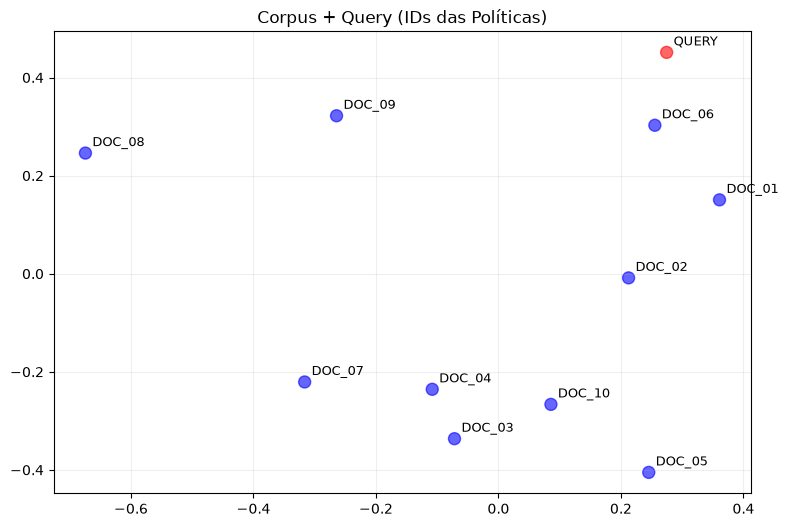

In [13]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Preparação para os plots de Busca
texts_with_query = df["text"].tolist() + [query_exemplo]
embeddings_with_query = model.encode(texts_with_query, normalize_embeddings=True)
coords = PCA(n_components=2).fit_transform(embeddings_with_query)

query_plot_df = pd.DataFrame({
    "label": df["id"].tolist() + ["QUERY"],
    "text": texts_with_query,
    "x": coords[:, 0],
    "y": coords[:, 1]
})

# Cores dinâmicas: azul para documentos, vermelho para a query
colors = ['blue'] * (len(query_plot_df) - 1) + ['red']

# Versão com IDs das Políticas
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(query_plot_df["x"], query_plot_df["y"], s=75, c=colors, alpha=0.6)

for _, row in query_plot_df.iterrows():
    ax.annotate(
        row["label"],
        (row["x"], row["y"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

ax.set_title("Corpus + Query (IDs das Políticas)")
ax.grid(alpha=0.2)
plt.show()

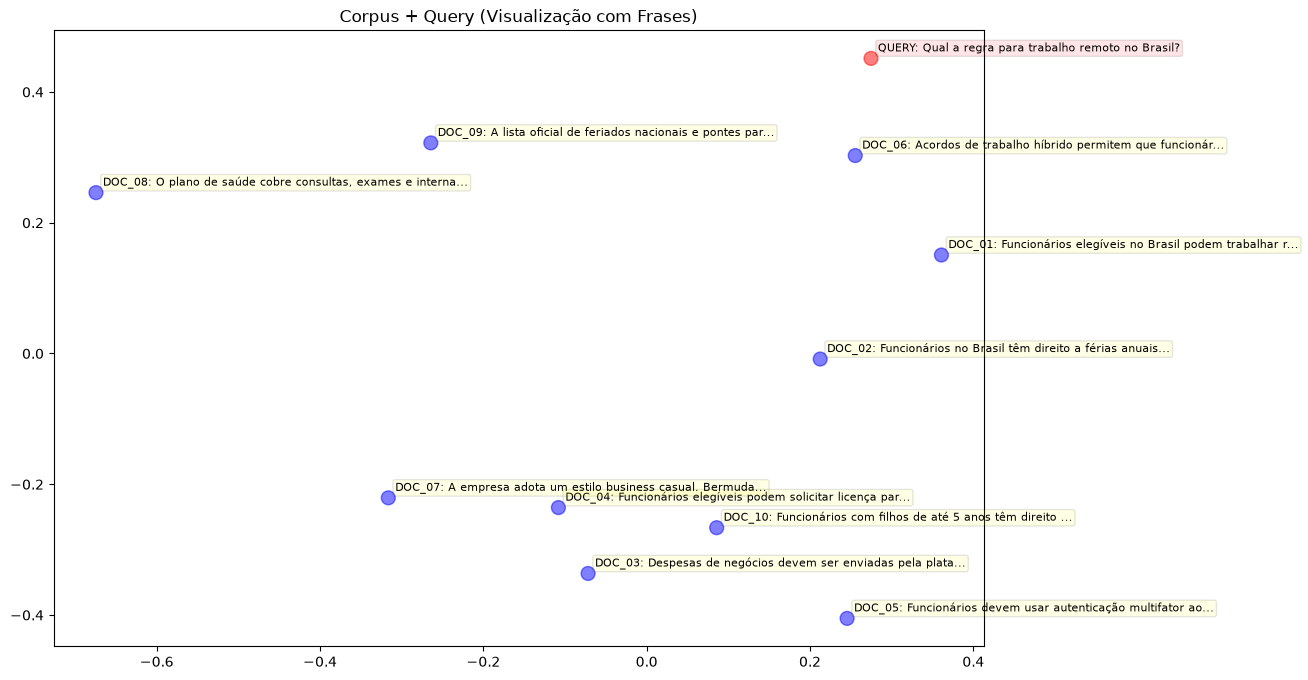

In [14]:
import matplotlib.pyplot as plt

# Versão 2: Visualização com Frases (Dinâmica)
colors = ['blue'] * (len(query_plot_df) - 1) + ['red']

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(query_plot_df["x"], query_plot_df["y"], s=100, c=colors, alpha=0.5)

for _, row in query_plot_df.iterrows():
    display_text = (row["text"][:50] + '...') if len(row["text"]) > 50 else row["text"]
    ax.annotate(
        f"{row['label']}: {display_text}",
        (row["x"], row["y"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.1) if row['label'] != 'QUERY' else dict(boxstyle='round,pad=0.2', fc='red', alpha=0.1)
    )

ax.set_title("Corpus + Query (Visualização com Frases)")
plt.show()

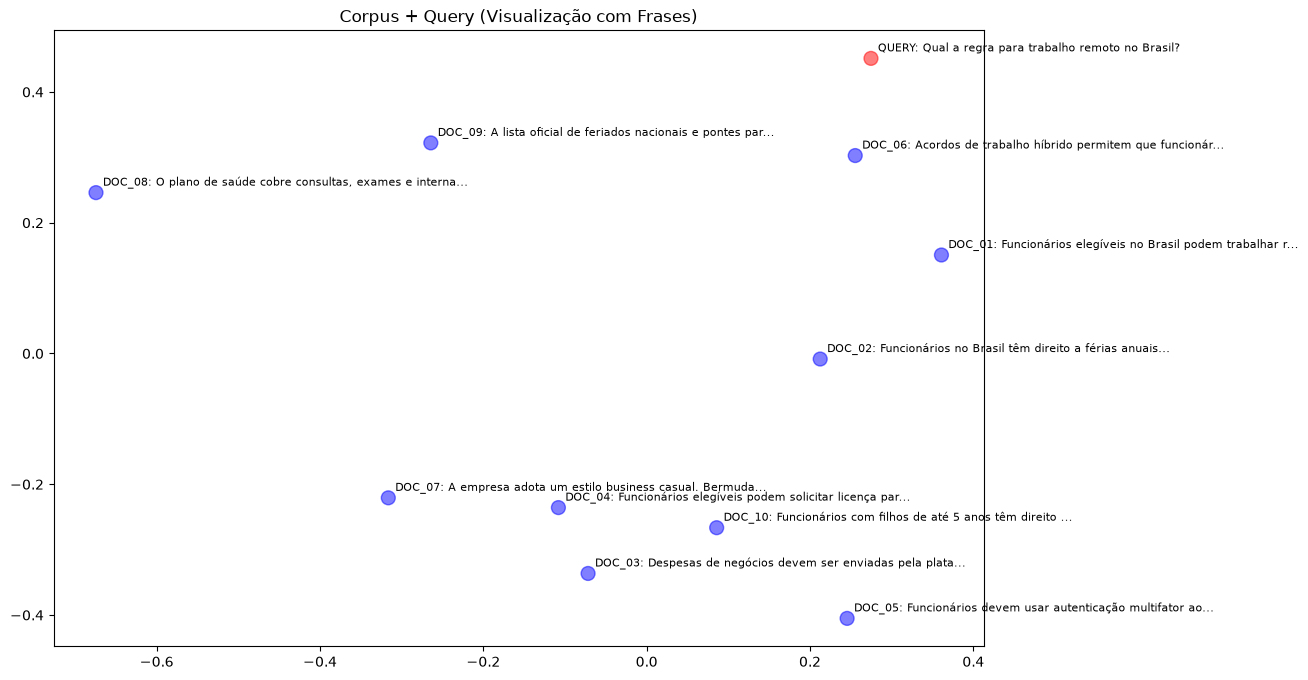

In [15]:
import matplotlib.pyplot as plt

# Gerar cores dinamicamente para evitar erro de dimensão
colors = ['blue'] * (len(query_plot_df) - 1) + ['red']

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(query_plot_df["x"], query_plot_df["y"], s=100, c=colors, alpha=0.5)

for _, row in query_plot_df.iterrows():
    display_text = (row["text"][:50] + '...') if len(row["text"]) > 50 else row["text"]
    ax.annotate(
        f"{row['label']}: {display_text}",
        (row["x"], row["y"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

ax.set_title("Corpus + Query (Visualização com Frases)")
plt.show()


# 8. Agora vamos quebrar o retrieval

Considere duas políticas quase idênticas:

**2024:** trabalho remoto até **2 dias** por semana.  
**2026:** trabalho remoto até **3 dias** por semana.

Uma está obsoleta, mas ambas são semanticamente muito próximas da pergunta.


In [16]:
conflicting_documents = [
    {
        "id": "POLICY_2024",
        "title": "Política de Trabalho Remoto — Brasil — 2024",
        "country": "Brasil",
        "year": 2024,
        "status": "inactive",
        "text": "Funcionários elegíveis no Brasil podem trabalhar remotamente até dois dias por semana."
    },
    {
        "id": "POLICY_2026",
        "title": "Política de Trabalho Remoto — Brasil — 2026",
        "country": "Brasil",
        "year": 2026,
        "status": "active",
        "text": "Funcionários elegíveis no Brasil podem trabalhar remotamente até três dias por semana."
    },
    {
        "id": "VACATION_2026",
        "title": "Política de Férias — Brasil — 2026",
        "country": "Brasil",
        "year": 2026,
        "status": "active",
        "text": "Funcionários no Brasil podem solicitar férias anuais remuneradas conforme a política da empresa."
    }
]

conflict_df = pd.DataFrame(conflicting_documents)
conflict_embeddings = model.encode(
    conflict_df["text"].tolist(),
    normalize_embeddings=True
)

# Buscando com a query em português
retrieve(
    "Quantos dias por semana funcionários no Brasil podem trabalhar remotamente?",
    conflict_df,
    conflict_embeddings,
    top_k=3
)

Embedding da query: 0.0093 s
Retrieval total:    0.0107 s


,id,title,text,similarity
0,POLICY_2024,Política de Trabalho Remoto — Brasil — 2024,Funcionários elegíveis no Brasil podem trabalhar remotamente até dois dias por semana.,0.879849
1,POLICY_2026,Política de Trabalho Remoto — Brasil — 2026,Funcionários elegíveis no Brasil podem trabalhar remotamente até três dias por semana.,0.871817
2,VACATION_2026,Política de Férias — Brasil — 2026,Funcionários no Brasil podem solicitar férias anuais remuneradas conforme a política da empresa.,0.486695



## Insight

> **Embeddings não conhecem, por si só, a política de versionamento da empresa.**

Agora entram:
- metadata;
- validade;
- país;
- permissões;
- fonte autoritativa;
- reranking.


## 9. Metadata filtering antes da busca

In [17]:
eligible_df = conflict_df[
    (conflict_df["country"].isin(["Brasil", "Brazil"])) &
    (conflict_df["status"].isin(["active", "ativo"]))
].copy()

eligible_embeddings = model.encode(
    eligible_df["text"].tolist(),
    normalize_embeddings=True
)

retrieve(
    "Quantos dias por semana funcionários no Brasil podem trabalhar remotamente?",
    eligible_df,
    eligible_embeddings,
    top_k=3
)

Embedding da query: 0.0100 s
Retrieval total:    0.0115 s


,id,title,text,similarity
0,POLICY_2026,Política de Trabalho Remoto — Brasil — 2026,Funcionários elegíveis no Brasil podem trabalhar remotamente até três dias por semana.,0.871817
1,VACATION_2026,Política de Férias — Brasil — 2026,Funcionários no Brasil podem solicitar férias anuais remuneradas conforme a política da empresa.,0.486695



# 10. Do embedding à arquitetura de conhecimento

```text
Documents
   ↓
Chunking
   ↓
Embeddings
   ↓
Index
   ↓
Metadata / permissions
   ↓
Query embedding
   ↓
Semantic retrieval
   ↓
Top-k / reranking
   ↓
Context assembly
   ↓
LLM
   ↓
Answer
```

### Principal insight

**RAG não é "LLM + documentos".**

A resposta final depende de uma cadeia de decisões arquiteturais.


## 11. Conectando ao LLM (Geração)

Agora que temos os documentos mais relevantes recuperados via similaridade semântica e filtrados por metadados, o próximo passo é passá-los para um LLM (como o GPT-4 da OpenAI) para redigir a resposta final baseada apenas nesse contexto.

In [ ]:
!pip install -q openai

In [20]:
import openai
import os
from dotenv import load_dotenv

load_dotenv()

def generate_answer(query, retrieved_df):
    """
    Monta o prompt com o contexto e envia para a OpenAI.
    """
    # 1. Preparar o contexto a partir dos documentos recuperados
    context = "\n\n".join([
        f"Documento: {row['title']}\nConteúdo: {row['text']}"
        for _, row in retrieved_df.iterrows()
    ])

    # 2. Criar o Prompt (System + User)
    system_prompt = (
        "Você é um assistente corporativo útil. Responda à pergunta do usuário usando APENAS "
        "o contexto fornecido abaixo. Se a resposta não estiver no contexto, diga que não sabe."
    )

    user_prompt = f"Contexto:\n{context}\n\nPergunta: {query}"

    # 3. Chamada da API (Requer OPENAI_API_KEY nos Secrets)
    try:
        client = openai.OpenAI(api_key=os.getenv('OPENAI_API_KEY'))
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            temperature=0
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"Erro na API (Verifique sua chave): {str(e)}\n\n--- Prompt que seria enviado ---\n{user_prompt}"

### Demonstração do Fluxo Completo de RAG

Vamos perguntar sobre o trabalho remoto, recuperar o documento ativo de 2026 e ver a resposta gerada.

In [24]:
pergunta = "Trabalho no Brasil. Eu posso tirar férias?"

# Passo 1: Retrieval + Filtro (Usando o que fizemos na seção 9)
contexto_recuperado = retrieve(
    pergunta,
    eligible_df,
    eligible_embeddings,
    top_k=5
)

# Passo 2: Geração
resposta_final = generate_answer(pergunta, contexto_recuperado)

print("\n=== RESPOSTA DO LLM ===\n")
print(resposta_final)
print("\n=== CONTEXTO RECUPERADO ===\n")
print(contexto_recuperado)

Embedding da query: 0.0183 s
Retrieval total:    0.0203 s

=== RESPOSTA DO LLM ===

Sim, funcionários no Brasil podem solicitar férias anuais remuneradas conforme a política da empresa.

=== CONTEXTO RECUPERADO ===

              id                                        title  \
0    POLICY_2026  Política de Trabalho Remoto — Brasil — 2026   
1  VACATION_2026           Política de Férias — Brasil — 2026   

                                                                                               text  \
0            Funcionários elegíveis no Brasil podem trabalhar remotamente até três dias por semana.   
1  Funcionários no Brasil podem solicitar férias anuais remuneradas conforme a política da empresa.   

   similarity  
0    0.645365  
1    0.518379  
